In [14]:
from pathlib import Path
import pandas as pd
from mordred import Calculator, descriptors
from rdkit.Chem import PandasTools, AddHs
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold
from pygad import GA
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

In [47]:
file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
df["ROMol"] = [AddHs(mol) for mol in df["ROMol"]]

calc = Calculator(descriptors, ignore_3D = True)
df1 = calc.pandas(df["ROMol"])
df1 = df1.apply(pd.to_numeric, errors = "coerce")
df1 = df1.fillna(0)

100%|██████████| 88/88 [00:01<00:00, 54.19it/s]


In [49]:
var_selector = VarianceThreshold(threshold = 0.01)
df1_var = var_selector.fit_transform(df1)
selected_columns = df1.columns[var_selector.get_support()]
df2 = pd.DataFrame(df1_var, columns = selected_columns)

corr = df2.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
df2 = df2.drop(columns = to_drop)

Importances = RandomForestRegressor(n_estimators = 300).fit(StandardScaler().fit_transform(df2.values), df["Q(cal/g)"]).feature_importances_
feature_importances = pd.Series(Importances, index = df2.columns)
feature_importances = feature_importances.sort_values(ascending = False)

df2 = df2[feature_importances.index].iloc[:, : 70]
df2

,AATS0dv,VSA_EState3,AATS4d,GATS1Z,ATSC1v,MDEN-23,AATS0d,AATS7se,AATS6dv,MATS1c,...,Xch-6d,AATS7dv,MDEO-22,AMID_N,GATS5dv,MAXaaN,IC1,GATS7s,GATS3d,ATSC4d
0,11.750000,0.000000,1.785714,0.775617,95.426894,0.500000,3.375000,0.000000,0.000000,-0.718103,...,0.055556,0.000000,0.000000,0.753260,0.758842,0.000000,3.149397,0.000000,1.232575,-2.812500
1,20.111111,22.672656,3.954545,0.602578,36.665356,1.440403,4.388889,9.646817,11.357143,-0.711022,...,0.337267,14.692308,0.333333,0.920630,0.617399,3.442954,3.127987,0.937377,0.776650,-2.876543
2,19.636364,35.194105,4.147059,0.515236,68.635275,6.545285,4.272727,9.956962,12.666667,-0.121994,...,0.274972,13.370370,0.000000,1.130056,0.813567,3.634735,3.516028,2.119257,1.028057,-2.355372
3,13.545455,28.213869,3.545455,0.635497,35.747257,2.994923,4.181818,8.020383,7.916667,-0.657927,...,0.402411,7.500000,0.000000,1.267785,1.172659,4.049907,3.641250,0.768266,0.912474,-1.363636
4,16.173913,28.644779,3.250000,0.461554,-105.102843,3.218254,4.000000,9.274893,7.838710,0.007514,...,0.219416,14.850000,0.000000,0.735362,1.209438,3.712630,3.497056,0.505590,1.159801,-0.625709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,25.071429,35.269156,4.106383,0.488793,9.251412,5.614343,4.714286,10.451152,20.575000,-0.249132,...,0.262486,21.761905,0.200000,0.787384,0.697581,3.384899,4.155046,1.086026,1.181250,7.000000
84,16.526316,15.891380,3.384615,0.602281,35.368995,1.310371,3.631579,9.212626,7.166667,-0.749290,...,0.083333,8.357143,0.000000,0.694528,0.745098,3.356617,3.787144,0.885611,0.975676,-7.252078
85,15.125000,23.508034,3.590909,0.658981,129.819098,1.486748,4.187500,9.187194,8.520548,-0.978754,...,0.550267,8.456522,0.333333,0.730219,1.096873,0.000000,3.538910,1.838992,1.215876,-7.531250
86,24.666667,42.492431,2.260870,0.518895,50.403226,3.464102,4.666667,0.000000,0.000000,0.160085,...,0.187500,0.000000,0.000000,0.981770,2.714905,0.000000,3.044110,0.000000,1.765563,7.456790


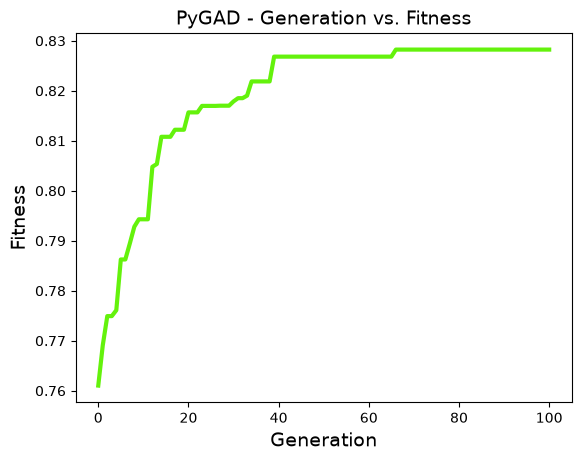

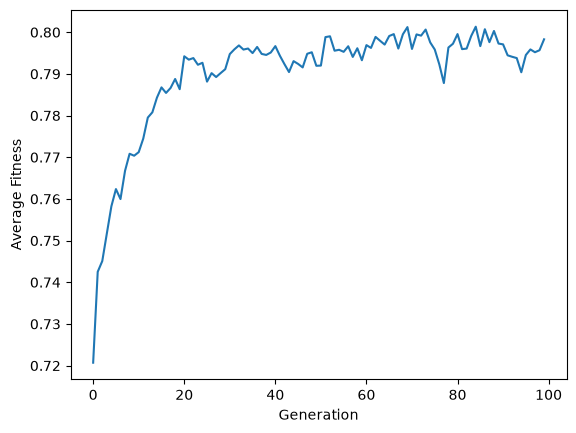

Index(['AATS0dv', 'VSA_EState3', 'AATS4d', 'GATS1Z', 'ATSC1v', 'ATSC1c',
       'MIC0', 'EState_VSA8', 'GATS1se', 'ATSC1Z', 'AATS5s', 'AATS4p',
       'BCUTm-1h', 'AATSC0dv', 'ATSC1se', 'nHBDon', 'GATS2se', 'AATS8dv',
       'GATS1v', 'AATS6s', 'FilterItLogS'],
      dtype='str')

In [50]:
def fitness(ga_instance, solution, solution_idx):
    selected = np.where(solution == 1)[0]
    if len(selected) == 0:
        return -1e6
    rf = RandomForestRegressor(
        n_estimators = 80,
        max_depth = None,
        random_state = 323922
    )
    score = cross_validate(
        rf, StandardScaler().fit_transform(x_all[:, selected]), y_all, 
        cv = KFold(n_splits = 5, shuffle = True, random_state = 323922),
        scoring = "r2",
        n_jobs = -1
    )
    return score["test_score"].mean()

x_all = df2.values
y_all = df["Q(cal/g)"]
df2

avg_list = []
def on_gen(ga):
    fit = ga.last_generation_fitness
    if fit is not None:
        avg_list.append(np.mean(fit))

ga = GA(
    sol_per_pop = 150,
    num_genes = 70,
    gene_space = [0, 1],
    gene_type = int,
    fitness_func = fitness,
    keep_elitism = 1,
    parent_selection_type = "tournament",
    K_tournament = 4,
    num_parents_mating = 10,
    crossover_type = "two_points",
    mutation_percent_genes = 3,
    num_generations = 100,
    on_generation = on_gen,
    parallel_processing = 8
)

ga.run()

ga.plot_fitness()
plt.plot(avg_list)
plt.xlabel("Generation")
plt.ylabel("Average Fitness")
plt.show()

best_solution = ga.best_solution()[0]
df3 = df2.iloc[:, np.where(best_solution == 1)[0]].columns
df3

In [65]:
# def fitness(ga_instance, solution, solution_idx):
#     selected = np.where(solution == 1)[0]
#     if len(selected) < 5:
#         return -1e6
#     rf = RandomForestRegressor(
#         n_estimators = 80,
#         random_state = 114514
#     )
#     score = cross_validate(rf, x_all[:, selected], y_all, cv = 5, scoring = "r2", n_jobs = -1)
#     return score["test_score"].mean() - len(selected) / 50

# x_all = df2.values
# y_all = df["Q(cal/g)"]

# feature_count = np.zeros(50)
# seeds = [666, 888, 114514, 323922, 1919810]

# for seed in seeds:
#     ga = GA(
#         sol_per_pop = 100,
#         num_genes = 50,
#         gene_space = [0, 1],
#         gene_type = int,
#         fitness_func = fitness,
#         keep_elitism = 1,
#         parent_selection_type = 'tournament',
#         K_tournament = 3,
#         num_parents_mating = 10,
#         crossover_type = 'two_points',
#         mutation_percent_genes = 5,
#         num_generations = 40,
#         on_generation = on_gen,
#         random_seed = seed,
#         parallel_processing = 8
#     )
#     ga.run()
#     best_solution = ga.best_solution()[0]
#     selected = np.where(best_solution == 1)[0]
#     for idx in selected:
#         feature_count[idx] += 1

# top_k_idx = np.argsort(feature_count)[ : : -1][ : 15]
# names = df2.iloc[:, top_k_idx].columns
# names